<div style="background:linear-gradient(135deg,#0a1230 0%,#141d44 55%,#1b1448 100%);border-radius:18px;padding:36px 32px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#00d4ff;font-weight:700;text-transform:uppercase">Part III · Visualizing Data &nbsp;|&nbsp; Chapter 17</div>
  <div style="font-size:40px;font-weight:900;line-height:1.1;margin:10px 0 6px">Choosing the Right Visualization <span style="color:#00d4ff">🐍 Notebook</span></div>
  <div style="font-size:16px;color:#b9c2e0;max-width:720px;line-height:1.6">Five demos that put chart choice on a framework: the same data shown four ways, a chooser working question by question, when not to chart at all, and a default chart made over into a clear explanatory one.</div>
  <div style="margin-top:18px;font-size:13px;color:#8892b0">Author: <b style="color:#e8eaf6">John Fisher</b> &nbsp;·&nbsp; Statistics, Data Science and AI: A Visual Handbook &nbsp;·&nbsp; 2026</div>
</div>

### 🎯 What you'll build in this notebook

| # | Demo | Idea it builds |
|---|------|----------------|
| 1 | Same data, four ways | the question, not the data, picks the chart |
| 2 | The chooser in action | one dataset, four questions, four charts |
| 3 | Do you even need a chart? | sometimes a number or a table wins |
| 4 | Default to explanatory | a makeover: declutter, focus, title the takeaway |
| 5 | A quick-reference matrix | purpose and data type to chart |

---

## ⚙️ Setup, imports & the book's plotting style

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(17)

NAVY="#0a1230"; INK="#1a2138"; INK_SOFT="#4a5578"
CYAN="#0891b2"; PURPLE="#7c3aed"; AMBER="#d97706"; GREEN="#059669"; PINK="#db2777"; BLUE="#2563eb"; GRID="#e6e9f2"; GRAY="#c7ccda"
plt.rcParams.update({
    "figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
    "axes.edgecolor":GRID,"axes.linewidth":1.2,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,
    "axes.spines.top":False,"axes.spines.right":False,"axes.titlesize":12.5,"axes.titleweight":"bold","axes.titlecolor":INK,
    "axes.labelcolor":INK_SOFT,"axes.labelsize":10.5,"xtick.color":INK_SOFT,"ytick.color":INK_SOFT,"legend.frameon":False,
})
print("✅ Environment ready.")

✅ Environment ready.


<div style="background:#e0f7fb;border-left:5px solid #0891b2;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0891b2;letter-spacing:1px">DEMO 1 · SAME DATA, FOUR WAYS</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">🔄 The question picks the chart</div>
<div style="color:#4a5578;margin-top:6px">One small dataset, four renderings. The data did not change; the right choice depends on what you want the reader to see. For comparing categories, the sorted bar wins; the pie is hard, the line is simply wrong (the categories are not ordered), and a table is best when exact values matter.</div>
</div>

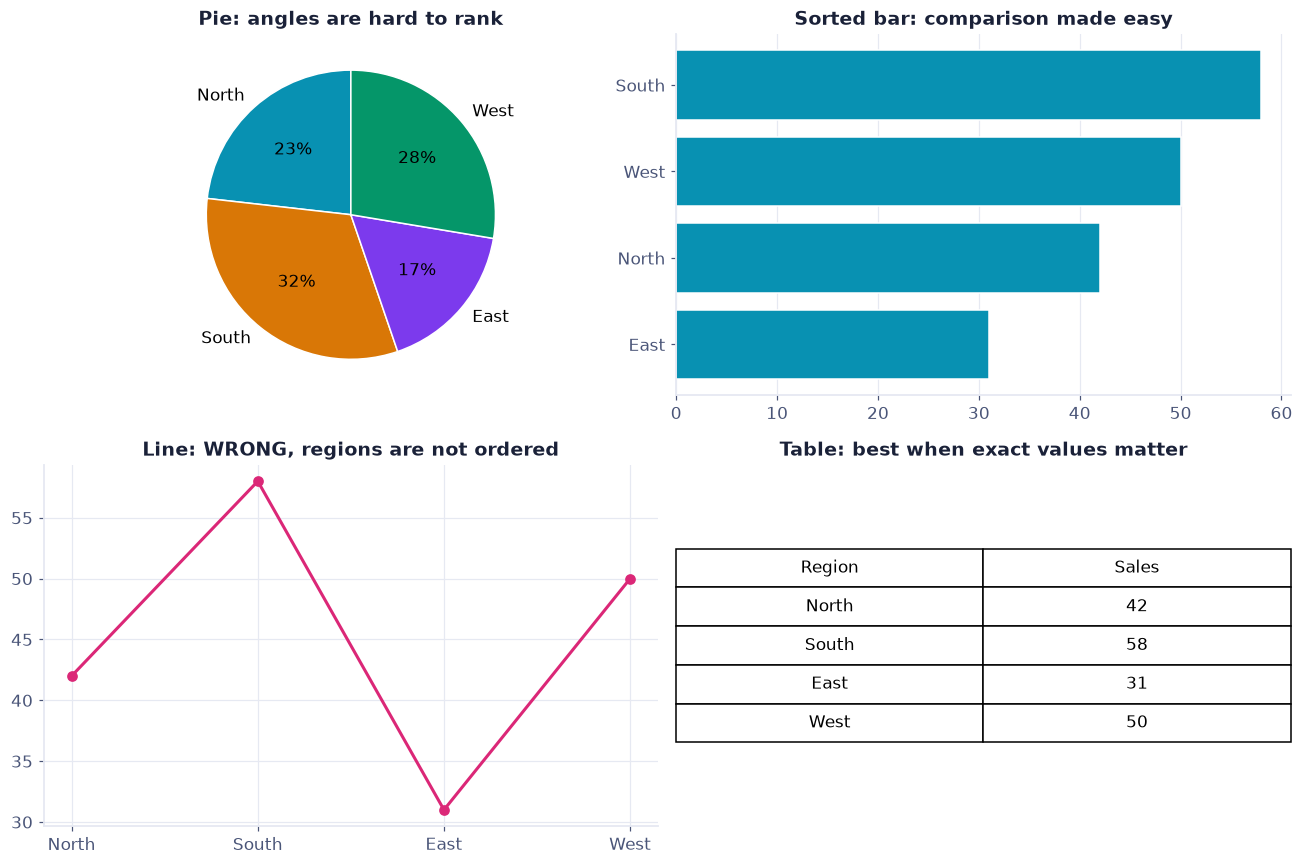

Comparison question -> sorted bar. The chart should serve the message, not the other way around.


In [2]:
regions = ["North","South","East","West"]
sales = np.array([42, 58, 31, 50.0])
order = np.argsort(sales)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0,0].pie(sales, labels=regions, autopct="%1.0f%%", startangle=90,
              colors=[CYAN,AMBER,PURPLE,GREEN], wedgeprops=dict(edgecolor="white"))
axes[0,0].set_title("Pie: angles are hard to rank")

axes[0,1].barh(np.array(regions)[order], sales[order], color=CYAN, edgecolor="white")
axes[0,1].set_title("Sorted bar: comparison made easy"); axes[0,1].grid(axis="y", visible=False)

axes[1,0].plot(regions, sales, "-o", color=PINK, lw=2)
axes[1,0].set_title("Line: WRONG, regions are not ordered")

axes[1,1].axis("off")
tbl = axes[1,1].table(cellText=[[r, f"{v:.0f}"] for r,v in zip(regions, sales)],
                      colLabels=["Region","Sales"], loc="center", cellLoc="center")
tbl.scale(1, 1.8); tbl.set_fontsize(11)
axes[1,1].set_title("Table: best when exact values matter")
plt.tight_layout(); plt.show()
print("Comparison question -> sorted bar. The chart should serve the message, not the other way around.")

<div style="background:#f0e9fe;border-left:5px solid #7c3aed;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#7c3aed;letter-spacing:1px">DEMO 2 · THE CHOOSER IN ACTION</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">🧭 Four questions, four charts</div>
<div style="color:#4a5578;margin-top:6px">Take one dataset and ask different questions. Each question names a purpose (comparison, trend, distribution, relationship), and the purpose names the chart.</div>
</div>

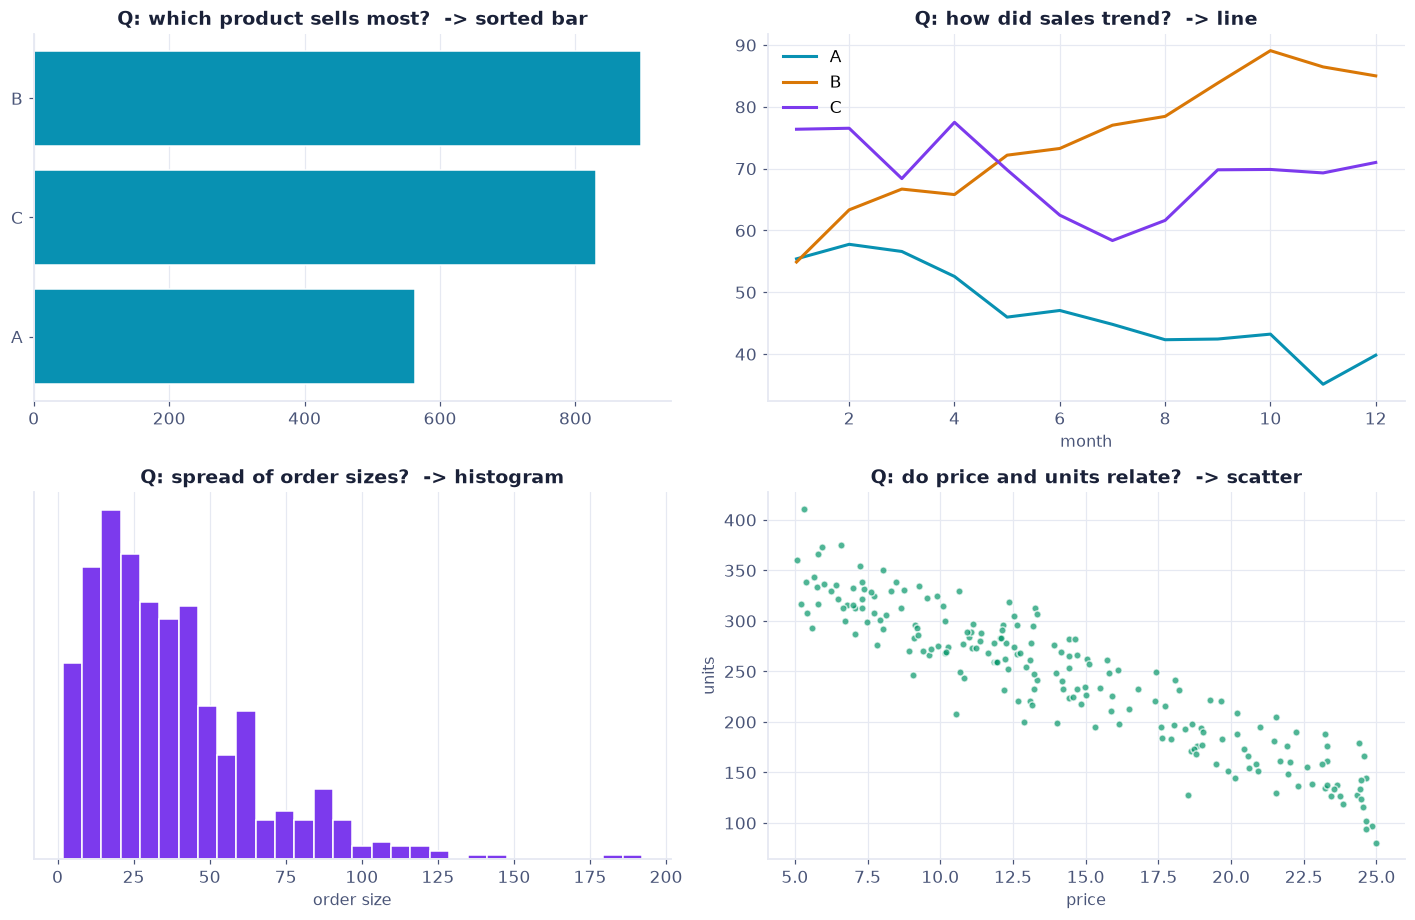

Same dataset, four purposes, four charts. Name the purpose first.


In [3]:
months = np.arange(1, 13)
products = ["A","B","C"]
monthly = {p: 50 + i*12 + np.cumsum(rng.normal(1, 4, 12)) for i,p in enumerate(products)}
order_sizes = rng.gamma(2.0, 18, 600)
price = rng.uniform(5, 25, 200); units = 400 - 11*price + rng.normal(0, 25, 200)

fig, ax = plt.subplots(2, 2, figsize=(13, 8.5))
# Q1 which product sells most overall? -> sorted bar (comparison)
totals = pd.Series({p: monthly[p].sum() for p in products}).sort_values()
ax[0,0].barh(totals.index, totals.values, color=CYAN, edgecolor="white"); ax[0,0].grid(axis="y", visible=False)
ax[0,0].set_title("Q: which product sells most?  -> sorted bar")
# Q2 how did sales trend? -> line (trend over time)
for p,c in zip(products,[CYAN,AMBER,PURPLE]): ax[0,1].plot(months, monthly[p], color=c, lw=2, label=p)
ax[0,1].set_title("Q: how did sales trend?  -> line"); ax[0,1].legend(); ax[0,1].set_xlabel("month")
# Q3 spread of order sizes? -> histogram (distribution)
ax[1,0].hist(order_sizes, bins=30, color=PURPLE, edgecolor="white"); ax[1,0].set_yticks([])
ax[1,0].set_title("Q: spread of order sizes?  -> histogram"); ax[1,0].set_xlabel("order size")
# Q4 do price and units relate? -> scatter (relationship)
ax[1,1].scatter(price, units, color=GREEN, s=22, alpha=0.7, edgecolor="white")
ax[1,1].set_title("Q: do price and units relate?  -> scatter"); ax[1,1].set_xlabel("price"); ax[1,1].set_ylabel("units")
plt.tight_layout(); plt.show()
print("Same dataset, four purposes, four charts. Name the purpose first.")

<div style="background:#fef3e2;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#d97706;letter-spacing:1px">DEMO 3 · DO YOU EVEN NEED A CHART?</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">🔢 Sometimes a number or a table wins</div>
<div style="color:#4a5578;margin-top:6px">A chart is not always the answer. One headline number is clearest as a big number. A few precise values readers must look up belong in a table. Save the chart for when shape, comparison, or trend is the point.</div>
</div>

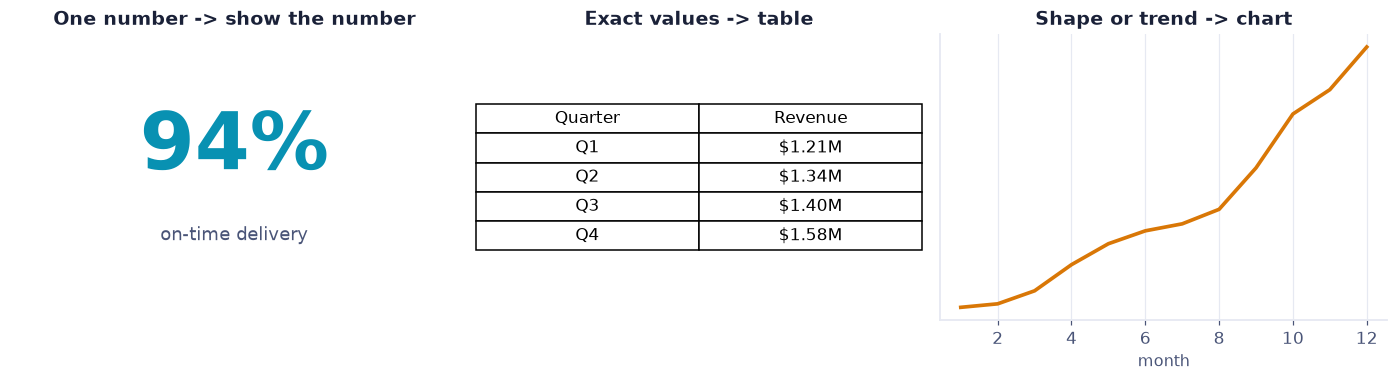

Gate every chart with: would a number or a table say this more clearly?


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))

# one key number -> just show it
axes[0].axis("off")
axes[0].text(0.5, 0.6, "94%", ha="center", va="center", fontsize=52, fontweight="bold", color=CYAN)
axes[0].text(0.5, 0.28, "on-time delivery", ha="center", fontsize=12, color=INK_SOFT)
axes[0].set_title("One number -> show the number")

# a few precise values -> table
axes[1].axis("off")
vals = [["Q1","$1.21M"],["Q2","$1.34M"],["Q3","$1.40M"],["Q4","$1.58M"]]
t = axes[1].table(cellText=vals, colLabels=["Quarter","Revenue"], loc="center", cellLoc="center")
t.scale(1, 1.7); t.set_fontsize(11)
axes[1].set_title("Exact values -> table")

# shape/trend -> chart
axes[2].plot(np.arange(1,13), np.cumsum(rng.normal(3,2,12))+20, color=AMBER, lw=2.4)
axes[2].set_title("Shape or trend -> chart"); axes[2].set_xlabel("month"); axes[2].set_yticks([])
plt.tight_layout(); plt.show()
print("Gate every chart with: would a number or a table say this more clearly?")

<div style="background:#fde8ef;border-left:5px solid #db2777;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#db2777;letter-spacing:1px">DEMO 4 · DEFAULT TO EXPLANATORY</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">💅 A chart makeover</div>
<div style="color:#4a5578;margin-top:6px">An exploratory default becomes an explanatory chart with four moves: sort, declutter, focus attention (gray the context, color the point), and retitle with the takeaway instead of the axes.</div>
</div>

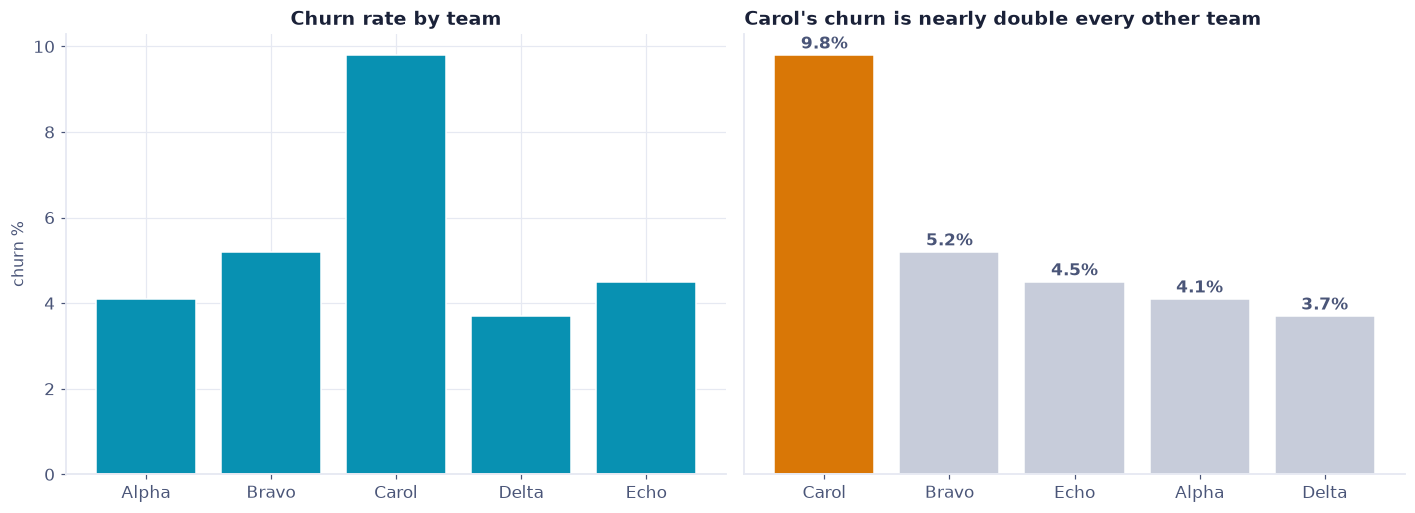

Same data. The makeover states a conclusion and points the eye straight at it.


In [5]:
teams = ["Alpha","Bravo","Carol","Delta","Echo"]
churn = np.array([4.1, 5.2, 9.8, 3.7, 4.5])

fig, (before, after) = plt.subplots(1, 2, figsize=(13, 4.8))

# BEFORE: alphabetical, all one color, gridlines, axis-only title
before.bar(teams, churn, color=CYAN, edgecolor="white")
before.set_title("Churn rate by team"); before.set_ylabel("churn %")

# AFTER: sorted, context grayed, the problem bar highlighted, takeaway title, direct labels
idx = np.argsort(churn)[::-1]
t_sorted = [teams[i] for i in idx]; c_sorted = churn[idx]
colors = [AMBER if v==churn.max() else GRAY for v in c_sorted]
after.bar(t_sorted, c_sorted, color=colors, edgecolor="white")
after.set_title("Carol's churn is nearly double every other team", loc="left", color=INK)
after.grid(False); after.set_yticks([])
for i,v in enumerate(c_sorted): after.text(i, v+0.15, f"{v}%", ha="center", fontweight="bold", color=INK_SOFT)
plt.tight_layout(); plt.show()
print("Same data. The makeover states a conclusion and points the eye straight at it.")

<div style="background:#e6effe;border-left:5px solid #2563eb;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#2563eb;letter-spacing:1px">DEMO 5 · A QUICK-REFERENCE MATRIX</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">🗂️ Purpose and data type to chart</div>
<div style="color:#4a5578;margin-top:6px">Two small lookup tables to keep nearby: one from the purpose you have in mind, one from the kind of data you hold.</div>
</div>

In [6]:
purpose = pd.DataFrame({
    "purpose": ["Comparison","Ranking","Composition","Distribution","Relationship","Trend over time"],
    "go-to chart": ["bar / grouped bar","sorted bar / dot","stacked or 100% bar, treemap","histogram / box / violin",
                    "scatter / bubble / heatmap","line chart"],
})
datatype = pd.DataFrame({
    "data": ["1 categorical","1 numeric","1 cat + 1 num","2 numeric","2 categorical","3+ variables"],
    "chart": ["bar of counts","histogram / box","bar (value per category)","scatter (or line if x ordered)",
              "grouped/stacked bar or heatmap","color + size + facets"],
})
print("BY PURPOSE\n", purpose.to_string(index=False))
print("\nBY DATA TYPE x VARIABLE COUNT\n", datatype.to_string(index=False))

BY PURPOSE
         purpose                  go-to chart
     Comparison            bar / grouped bar
        Ranking             sorted bar / dot
    Composition stacked or 100% bar, treemap
   Distribution     histogram / box / violin
   Relationship   scatter / bubble / heatmap
Trend over time                   line chart

BY DATA TYPE x VARIABLE COUNT
          data                          chart
1 categorical                  bar of counts
    1 numeric                histogram / box
1 cat + 1 num       bar (value per category)
    2 numeric scatter (or line if x ordered)
2 categorical grouped/stacked bar or heatmap
 3+ variables          color + size + facets


---
<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:24px 28px;font-family:Inter,sans-serif;box-shadow:0 8px 30px rgba(20,30,80,0.05)">
<div style="font-size:20px;font-weight:800;color:#1a2138">🎓 Recap</div>
<ul style="color:#4a5578;line-height:1.9;margin-top:10px">
<li>Choose from the <b>message and the data</b>, not from what looks impressive.</li>
<li>Name the <b>purpose</b> (comparison, composition, distribution, relationship, trend), and the purpose names the chart.</li>
<li>Cross <b>data type with variable count</b> to narrow the choice further.</li>
<li>Sometimes the best visual is a <b>number or a table</b>, not a chart.</li>
<li>Turn a default into an <b>explanatory</b> chart: sort, declutter, focus attention, and title the takeaway.</li>
</ul>
</div>

<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:18px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>